# `**ШЕРИНГОВЫЕ УСЛУГИ. Анализ спроса на самокаты.**`

## К нам "обратилась" компания, предоставляющая самокаты в аренду. Она не так давно вышла на рынок, успела накопить некоторые данные по поездкам и теперь желает оптимизировать свой бизнес - перейти на динамический тип ценообразования.

# Задача:проанализировать эффективность текущей деятельности компании,выявить факторы, влияющие на спрос.

# План:
# 0.Предобработка данных
# 1. Проведение расчетов и исследований.
#    1.1 Итоговая стоимость
#    1.2 Таблица почасовый трафик
 #   1.3 Корреляция между параметрами погоды
# 2.Проверка гипотез
# -наши гипотезы
# 3.Регрессивное моделирование
#    3.1 Факторы
#    3.2 Нюансы
# 4.Дашборд и презентация    
# 5. Сдача проекта

#**0.Предобработка. Знакомство с данными**

Два файла: weather.csv и rides.csv

# Weather.csv

In [9]:
import pandas as pd


# df = pd.read_csv('weather.csv')
#df.info()


 Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

#Rides.csv

In [12]:
# import pandas as pd


# df = pd.read_csv('rides.csv')
# df.info()

 0   Id - идентификатор поездки              
 1   Start Date - Start Datetime     
 2   End Date - End Datetime        
 3   Start Location - Start Location  
 4   Start District - Start District   
 5   End Location - End Location    
 6   End District - End District    
 7   Distance - Distance        
 8   Promo - применен ли промо-код на бесплатный старт    

# *Предобработаем данные по следующему плану:**

## 1. Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки)

# ДЛЯ НАСТИ: Затем сформировать подразделы, ориентируемся на слайд из презентации по предобработке. В подразделах не забываем выводить “до”, поясняя проблему, и результат “после” для проверки + выводы.
# Пояснения к шагам лучше писать в маркдаунах обычным текстом (а не комментариями в ячейках для кода, таким образом мы пишем только пояснения к самому коду, а не к смысловому шагу).


# **1.Проведение расчетов и исследований.**

- файл 1_week_clean.ipynb

In [19]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re


import matplotlib.pyplot as plt
PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

# Общая информация про файл rides.csv

In [21]:
df = pd.read_csv(PATH_OUT + '\\rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [25]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

removed = initial_count - final_count
print(f"Удалено дубликатов: {removed}")

Удалено дубликатов: 4883


##### Удалено дубликатов: 4883
##### Было: 102255, Стало: 97372

In [27]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


## Неявные дубликаты

In [29]:
print(df['Start Location'].unique(), df['Start District'].unique())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

#### Замена названий улиц

In [31]:
df['Start District'] = df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))
df['End District'] = df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['Start Location'] = df['Start Location'].apply(clean_street)
df['End Location'] = df['End Location'].apply(clean_street)

print(df['Start Location'].unique())
print(df['Start District'].unique())
df.head(10)

['шевченко' 'чехова' 'буденного' 'труда' 'первомайская' 'лесная'
 'пролетарская' 'комарова' 'западная' 'свободы' 'коммунальная' 'зеленая'
 'шоссейная' 'центральная' 'новая' 'энтузиастов' 'подгорная' 'восточная'
 'лермонтова' 'школьная' 'пушкина' 'рябиновая' 'солнечная' 'мичурина'
 'партизанская' 'вокзальная' 'комсомольская' 'майская' 'красноармейская'
 'рабочая' 'почтовая' 'дачная' 'заводская' 'ломоносова' 'карла маркса'
 'советская' 'красная' 'дзержинского' 'энергетиков' 'пионерская' 'ленина'
 'сиреневая' 'гагарина' 'юбилейная' 'цветочная' 'набережная' 'сосновая'
 'спортивная' 'полевая' 'строительная' 'озерная' 'горького' 'южная'
 'некрасова' 'молодежная' 'чкалова' 'речная' 'парковая' 'строителей'
 'кирова' 'матросова' 'садовая' 'колхозная' 'луговая' 'крупской'
 'октябрьская' 'березовая' 'вишневая' 'береговая' 'дружбы' 'калинина'
 'суворова' 'дорожная' 'свердлова' 'куйбышева' 'нагорная' 'космонавтов'
 'северная' 'московская' 'гоголя' 'овражная' 'победы' 'кооперативная'
 'совхозная' 'з

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0


#### Распределение улиц по районам

In [33]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [34]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 0


In [35]:
df.dropna(subset=["Distance"], inplace=True)
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

## Нормализация данных: добавление скорости, продолжительности поездки, сезоны

#### Приведение времени к формату datetime, добавление сезонов и промежутка дня

In [38]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()

#### Добавление длительности поездки, средней скорости

In [40]:
df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:10:09,09:49:56,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:15:12,09:26:01,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:19:13,09:40:03,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:21:42,09:39:04,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:28:00,10:02:08,34.133333,9.251367


## Аномалии и выбросы

#### Анализ дистанции: строк > 10000 и <=5 около 3363

##### Почему значения Distance < 100 м — это аномалия?
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [44]:
q1 = df['Distance'].quantile(0.25)
q2 = df['Distance'].quantile(0.50)  # или median()
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Distance'] < lower_bound) | (df['Distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3045.0
Q2 (Median): 3703.0
Q3 (75%): 4431.0
IQR (Q3 - Q1): 1386.0
Количество выбросов по Distance: 4676


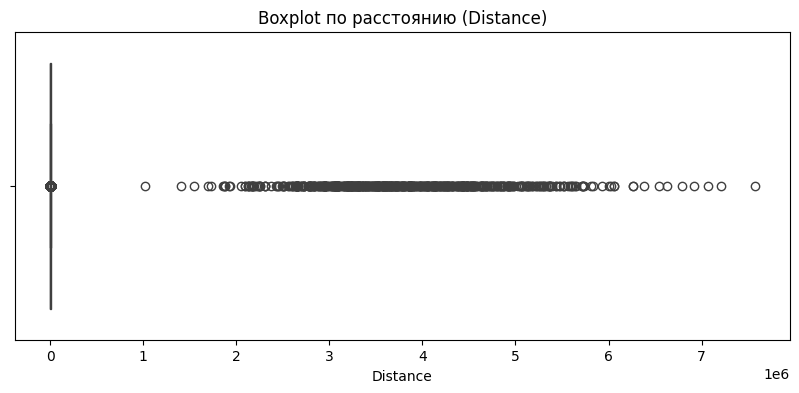

    Start Location  End Location   Distance   Duration
8         западная       озерная        3.0  17.366667
21      лермонтова        дружбы        5.0  29.433333
67          ленина      овражная        5.0  52.216667
70    строительная  строительная        4.0  17.900000
108      заводская     свердлова        4.0  33.466667
128     спортивная       свободы  4416111.0  29.966667
135        полевая    пионерская  6627165.0  49.450000
144      березовая       майская        4.0  37.350000
189        луговая         труда        4.0  42.383333
221   дзержинского     восточная        4.0  23.633333
Количество аномальных строк в Distance: 3514
Количество поездок с дистанцией меньше 100 м: 2923
Количество поездок с дистанцией более 10000 м: 591


In [58]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

anomalies_distance = df[(df['Distance'] <= 100) | (df['Distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['Start Location', 'End Location', 'Distance', 'Duration']].head(10))

low_distance_count = df[df['Distance'] < 100].shape[0]
high_distance_count = df[df['Distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Выбросы по Distance удалены.


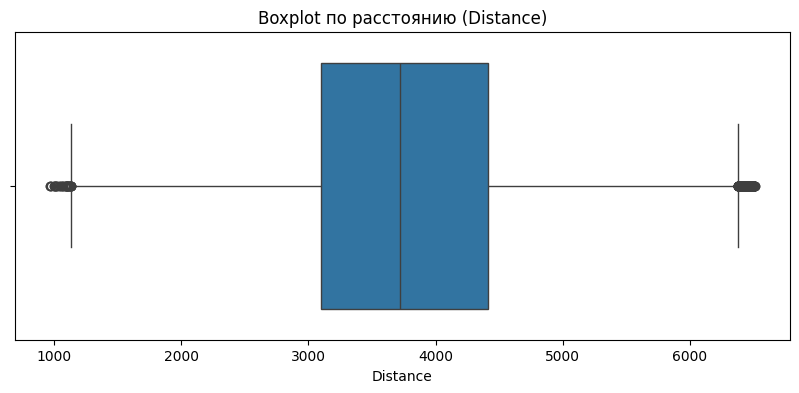

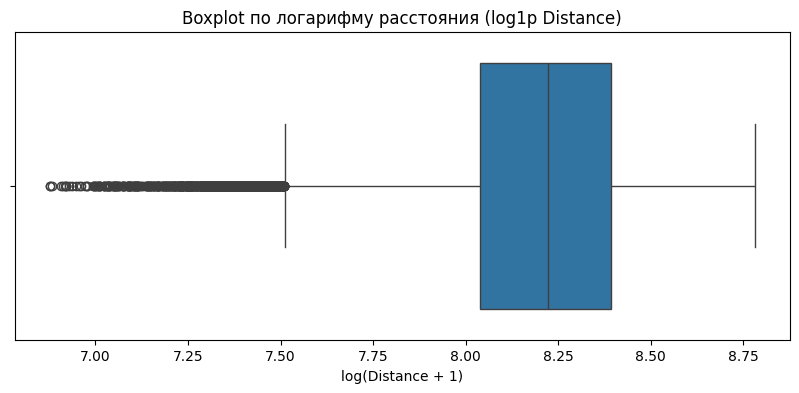

In [60]:
# condition = (df['Distance'] < 100) & (df['Duration'] > 8)
# print(f"Аномальных строк по условию Distance < 100 и Duration > 8 минут: {condition.sum()}")

# condition_large = (df['Distance'] > 10000) & (df['Duration'] < 60)
# print(f"Аномальных строк по условию Distance > 10000 м и Duration < 60 мин: {condition_large.sum()}")

# df = df[~condition_large]
# df = df[~condition]

# Квартильные границы
q1 = df['Distance'].quantile(0.25)
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Фильтрация датафрейма, убираем выбросы
df = df[(df['Distance'] >= lower_bound) & (df['Distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['Distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


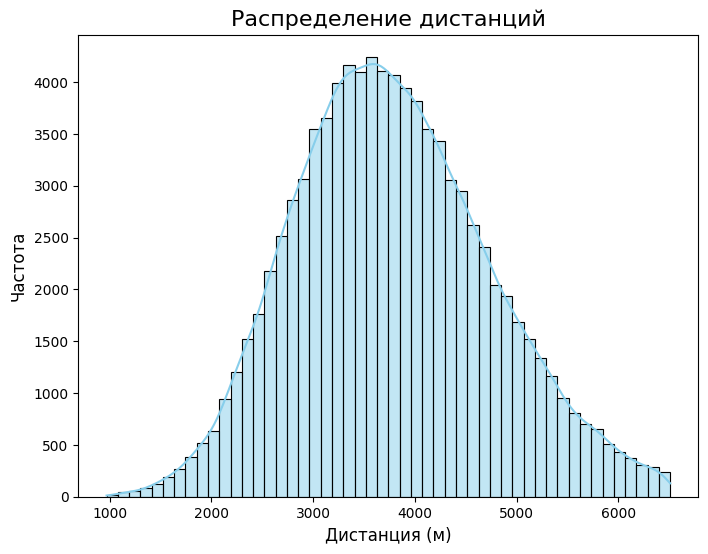

In [62]:
df = df[df['Distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

In [262]:
missing_end_date = df[df['End Date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['Start Date', 'End Date']].head(10))


Пропусков в 'End Date': 555
              Start Date End Date
312  2023-04-22 15:44:25      NaT
407  2023-04-22 16:52:47      NaT
486  2023-04-22 17:51:45      NaT
495  2023-04-22 17:58:05      NaT
753  2023-04-22 20:18:01      NaT
998  2023-04-22 23:33:50      NaT
1015 2023-04-23 00:00:22      NaT
1402 2023-04-23 15:24:09      NaT
2330 2023-04-24 16:39:31      NaT
2546 2023-04-24 19:41:16      NaT


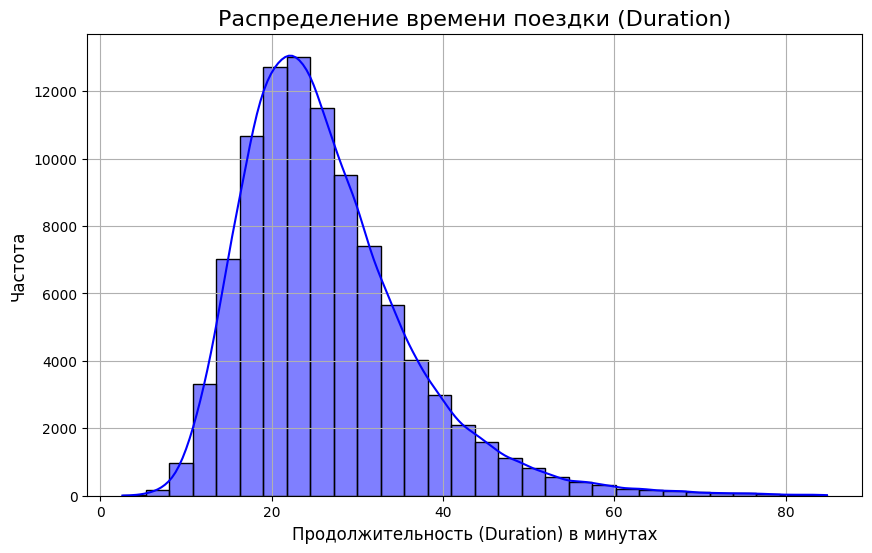

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

# Нормализация данных в столбцах DataFrame df

#Добавляем в DataFrame df новые признаки (колонки), которые помогают глубже анализировать данные поездок: когда они происходили, как долго длились, с какой скоростью и в какое время суток

In [ ]:
df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time Start,Time End,Duration,Speed (km/h),Time of Day,Day of Week,Start Hour
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266,Утро,Saturday,9
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138,Утро,Saturday,9
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860,Утро,Saturday,9
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806,Утро,Saturday,9
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826,Утро,Saturday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131,Ночь,Monday,23
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008,Ночь,Monday,23
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937,Ночь,Monday,23
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211,Ночь,Monday,23


#Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.

In [ ]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Time Start,Time End,Duration,Speed (km/h),Time of Day,Day of Week,Start Hour,Weekday,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,...,09:01:03,09:24:45,23.700000,10.301266,Утро,Saturday,9,5,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,...,09:01:07,09:29:32,28.416667,9.533138,Утро,Saturday,9,5,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,...,09:04:27,09:42:46,38.316667,7.077860,Утро,Saturday,9,5,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,...,09:06:34,09:38:23,31.816667,7.318806,Утро,Saturday,9,5,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,...,09:09:27,09:40:07,30.666667,7.882826,Утро,Saturday,9,5,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,...,23:45:06,00:06:55,21.816667,9.081131,Ночь,Monday,23,0,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,...,23:46:01,00:25:35,39.566667,7.570008,Ночь,Monday,23,0,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,...,23:48:04,00:09:21,21.283333,7.839937,Ночь,Monday,23,0,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,...,23:51:41,00:38:04,46.383333,8.364211,Ночь,Monday,23,0,5,231.916667


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

In [ ]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()




# Строим гистограмму распределения дистанций поездок

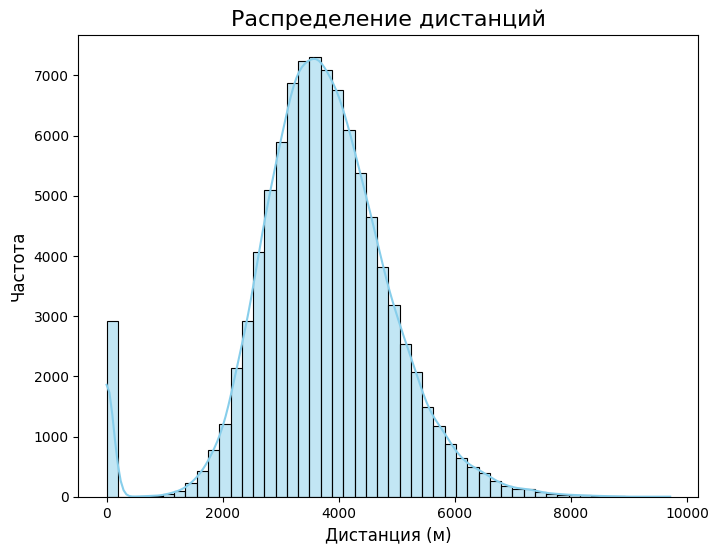

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

In [ ]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


df['Weekday'] = df['Start Date'].dt.weekday
df['Start Hour'] = df['Start Date'].dt.hour

df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

df['Trip Cost'] = df['Duration'] * df['Rate per Minute']
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Time Start,Time End,Duration,Speed (km/h),Time of Day,Day of Week,Start Hour,Weekday,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,...,09:01:03,09:24:45,23.700000,10.301266,Утро,Saturday,9,5,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,...,09:01:07,09:29:32,28.416667,9.533138,Утро,Saturday,9,5,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,...,09:04:27,09:42:46,38.316667,7.077860,Утро,Saturday,9,5,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,...,09:06:34,09:38:23,31.816667,7.318806,Утро,Saturday,9,5,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,...,09:09:27,09:40:07,30.666667,7.882826,Утро,Saturday,9,5,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,...,23:45:06,00:06:55,21.816667,9.081131,Ночь,Monday,23,0,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,...,23:46:01,00:25:35,39.566667,7.570008,Ночь,Monday,23,0,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,...,23:48:04,00:09:21,21.283333,7.839937,Ночь,Monday,23,0,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,...,23:51:41,00:38:04,46.383333,8.364211,Ночь,Monday,23,0,5,231.916667


# Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)

C:\Temp\ipykernel_18280\3707444050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time of Day', data=df, palette='Set2')


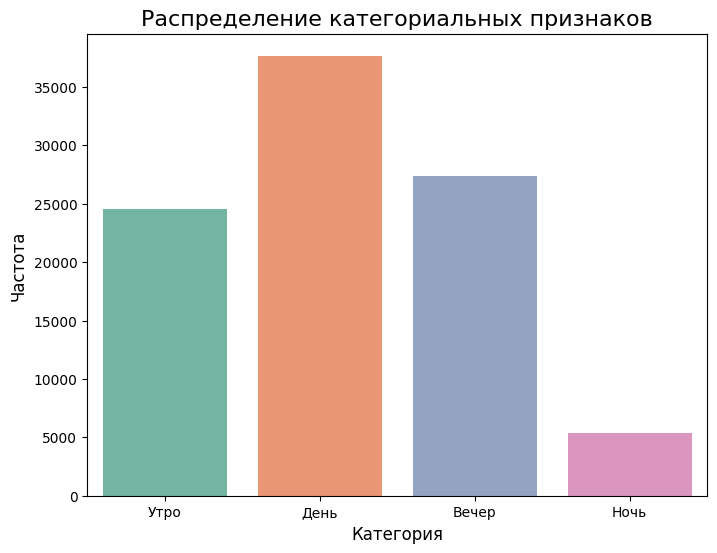

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

# Анализ распределения поездок по районам в будние и выходные дни.

In [ ]:
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               16024
1   Будний день    юго-восточный               11252
2   Будний день        ленинский                9413
3   Будний день  северо-западный                9375
4   Будний день      октябрьский                8023
5   Будний день         заречный                5568
6      Выходной      центральный                8373
7      Выходной    юго-восточный                6770
8      Выходной        ленинский                5763
9      Выходной  северо-западный                5739
10     Выходной      октябрьский                5047
11     Выходной         заречный                3539


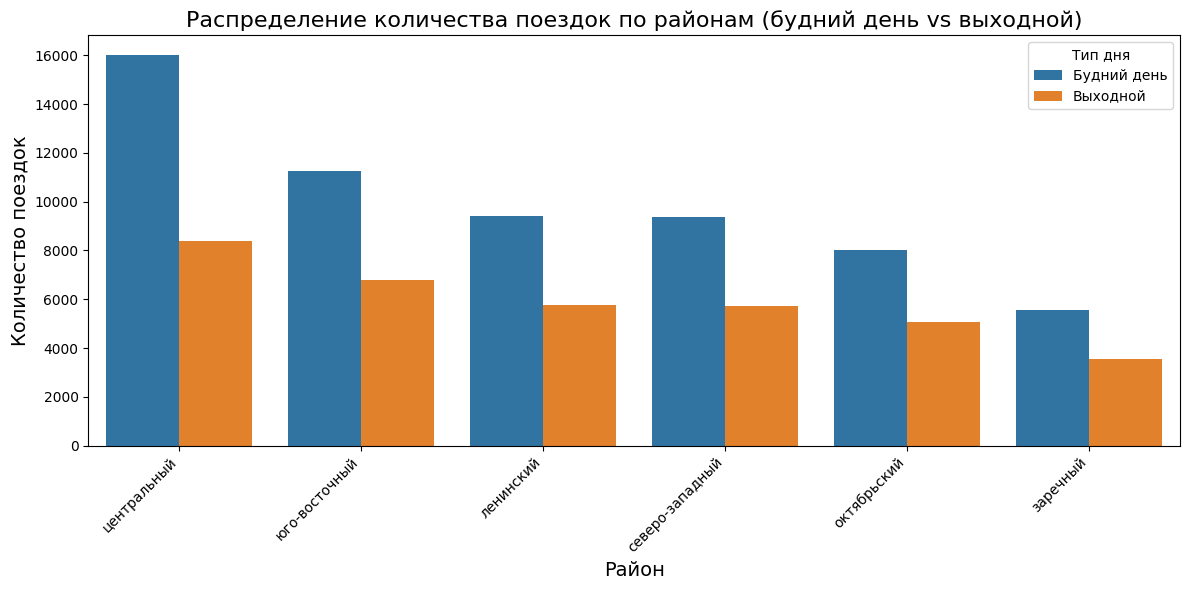

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

# Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

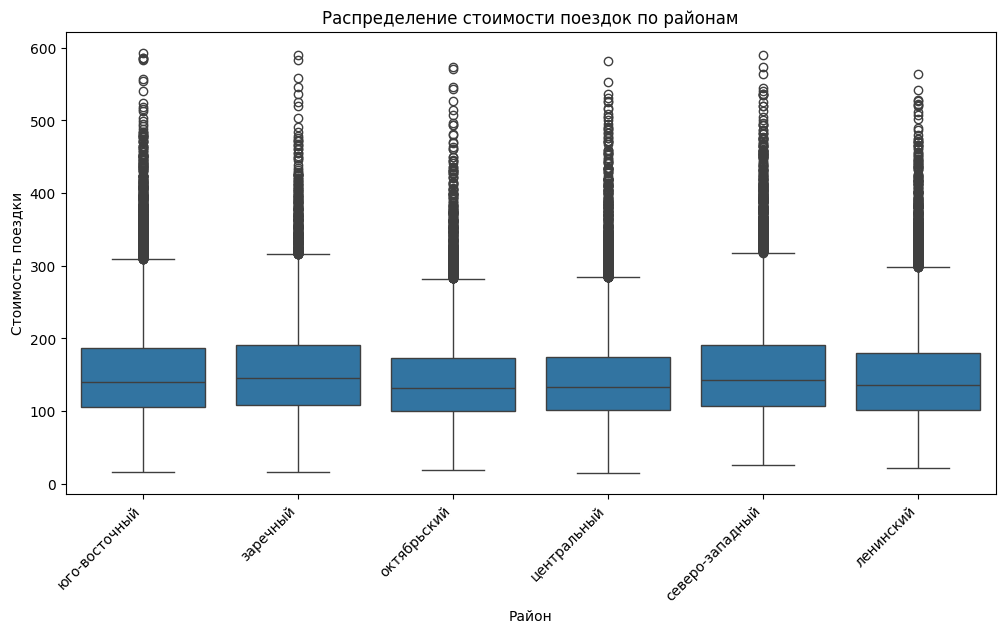

Start District
заречный           27.792169
северо-западный    27.683642
юго-восточный      27.183217
ленинский          26.145498
октябрьский        25.238809
центральный        25.200437
Name: Duration, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

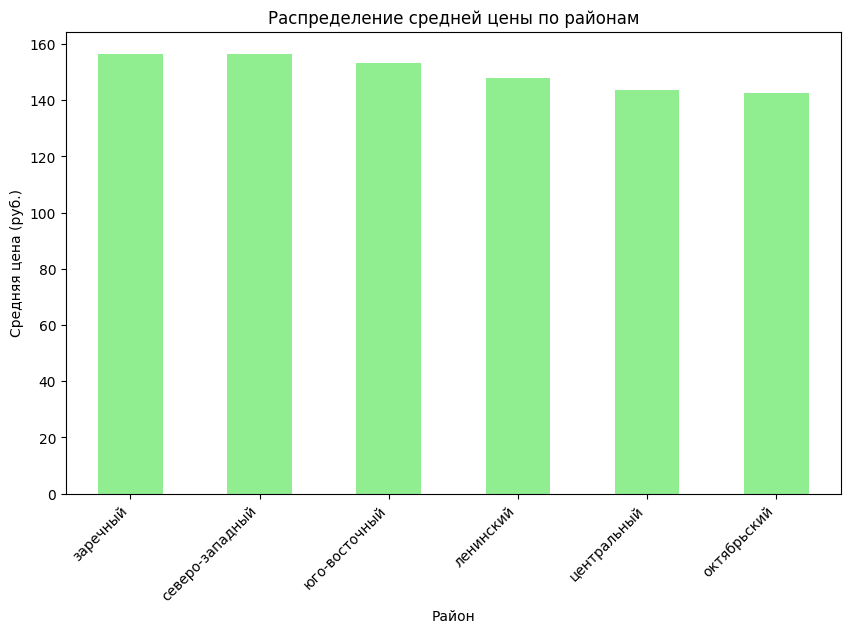

In [ ]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

#Выведем несколько значений.
# Среднее значение стоимости поездки:
# Максимальное значение стоимости поездки:
# Медиану стоимости поездки:


In [ ]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

149.17728010454653
593.3666666666667
137.41666666666669


# График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

C:\Temp\ipykernel_18280\615108698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")


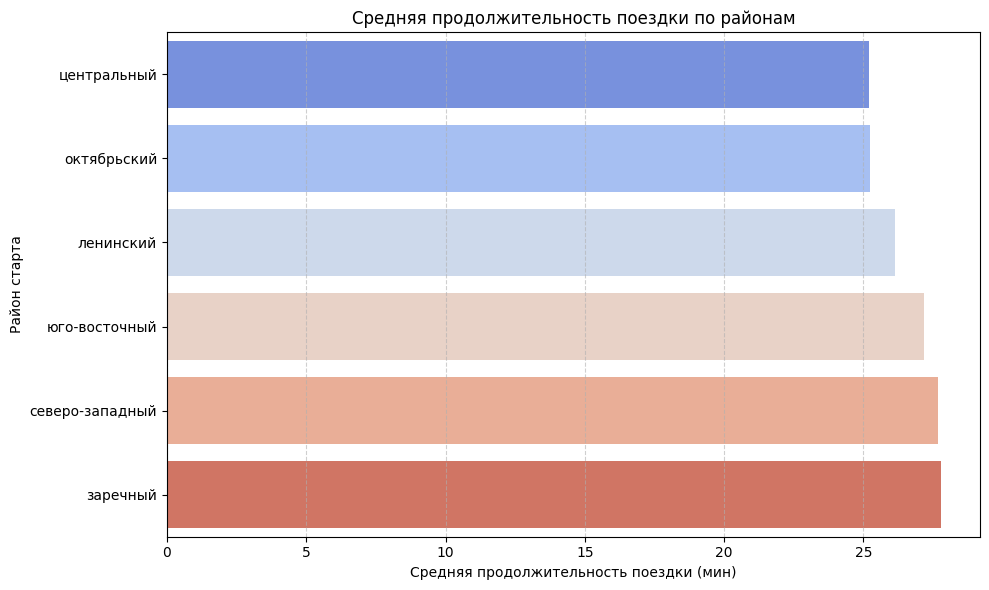

In [ ]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
#-Группировка данных по району старта и часу:
#-Сортировка районов по убыванию количества поездок:
#-Создание сводной таблицы (pivot table):
#-Сортировка таблицы по убыванию количества поездок в районах:
#-Построение тепловой карты (Heatmap):
#-Настройки графика:

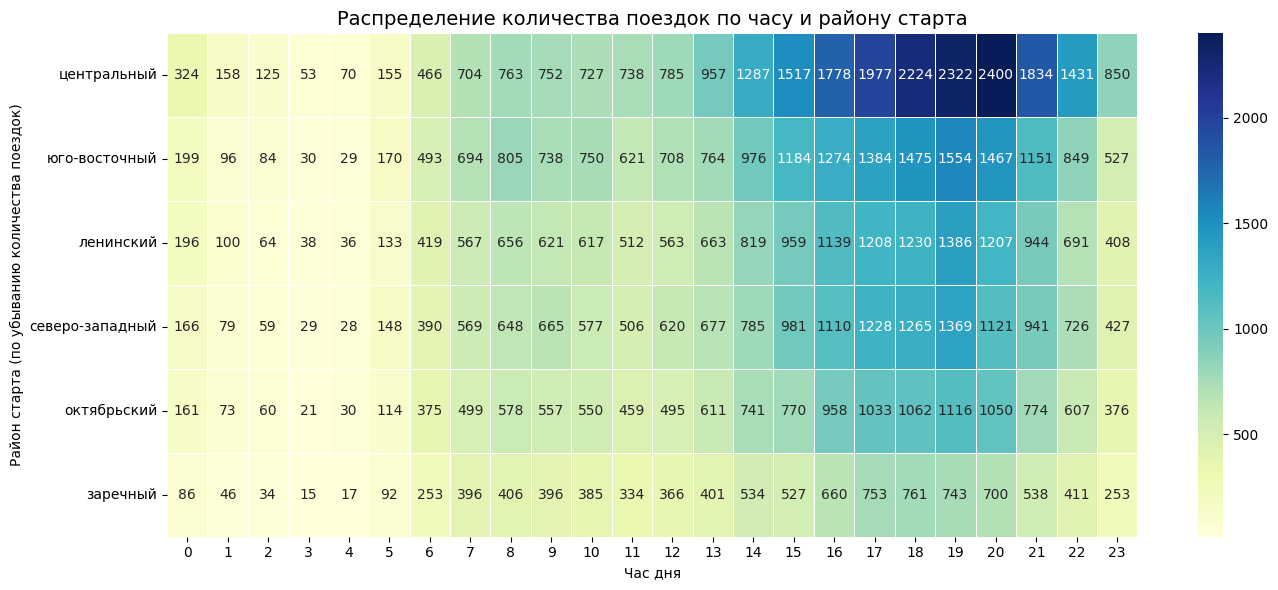

In [ ]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

# Два графика: boxplot (ящик с усами) и histplot (гистограмма) для колонки Distance (расстояние). Графики отображаются на одном холсте с использованием подграфиков (subplots).

D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` varia

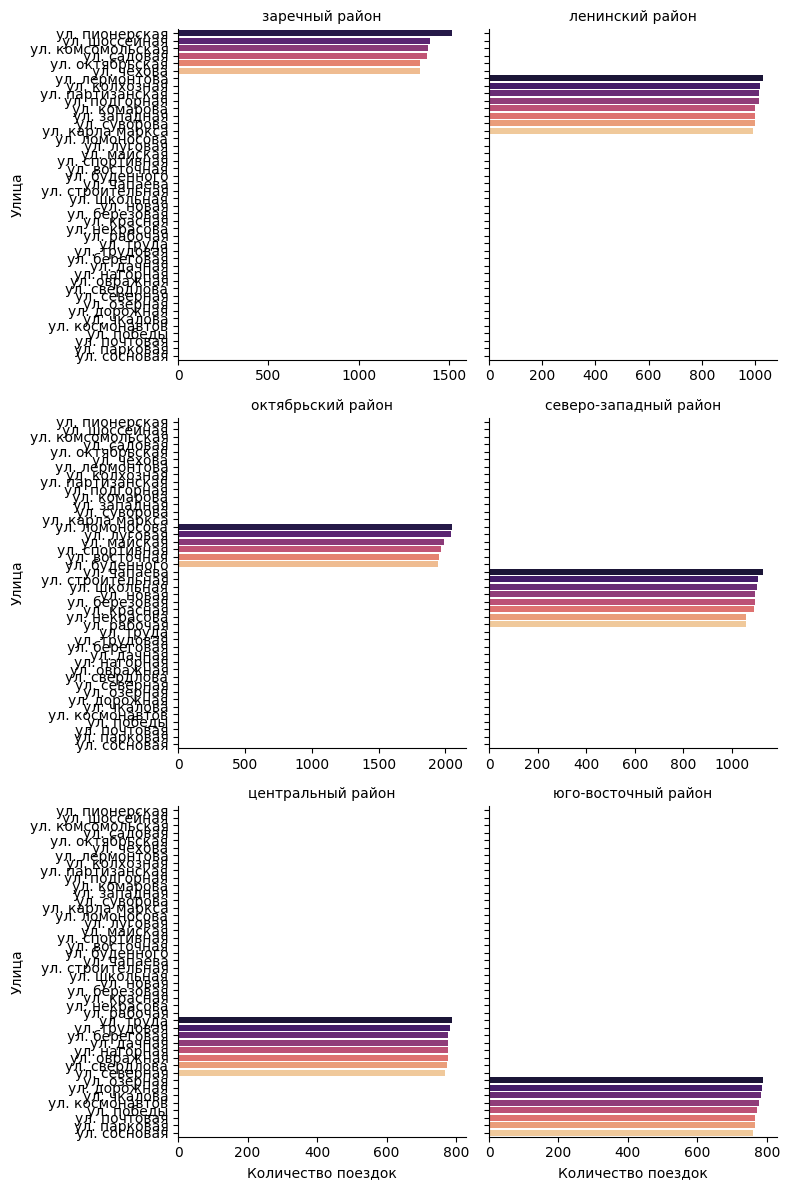

In [ ]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

# Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).

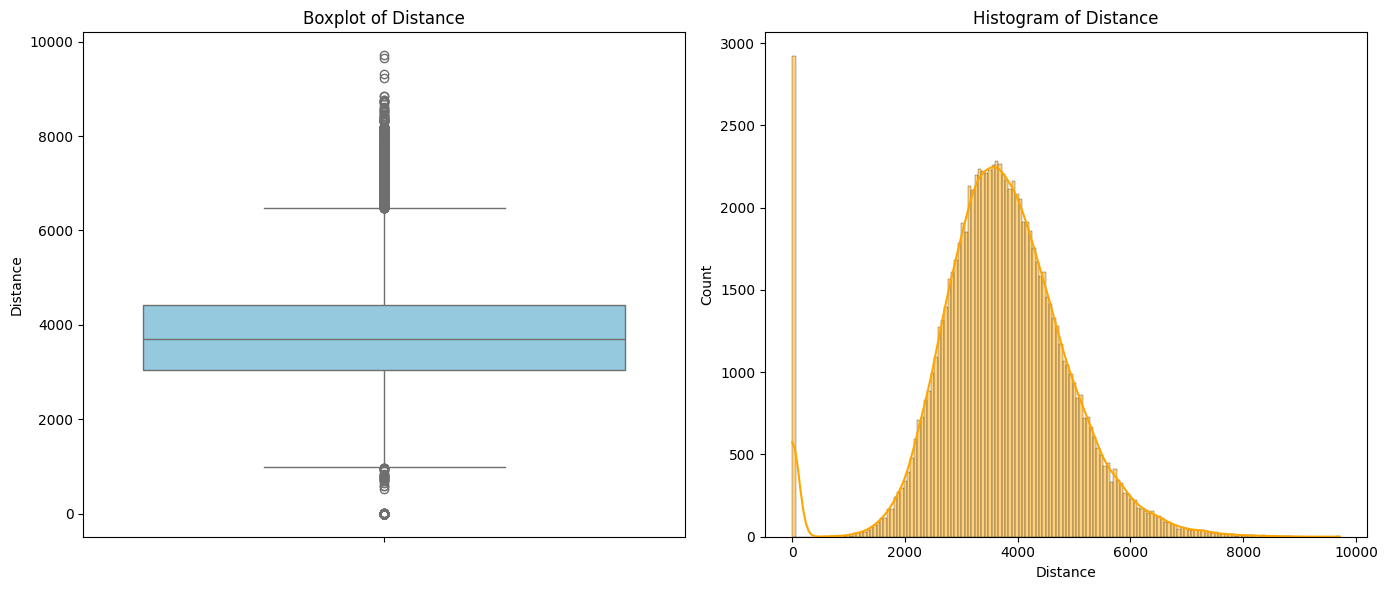

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()